In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [26]:
df = pd.read_csv('/content/creditcard.csv')

print(df.shape)

df.head()

(138723, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138723 entries, 0 to 138722
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    138723 non-null  int64  
 1   V1      138723 non-null  float64
 2   V2      138723 non-null  float64
 3   V3      138723 non-null  float64
 4   V4      138723 non-null  float64
 5   V5      138723 non-null  float64
 6   V6      138723 non-null  float64
 7   V7      138723 non-null  float64
 8   V8      138723 non-null  float64
 9   V9      138723 non-null  float64
 10  V10     138723 non-null  float64
 11  V11     138723 non-null  float64
 12  V12     138723 non-null  float64
 13  V13     138723 non-null  float64
 14  V14     138722 non-null  float64
 15  V15     138722 non-null  float64
 16  V16     138722 non-null  float64
 17  V17     138722 non-null  float64
 18  V18     138722 non-null  float64
 19  V19     138722 non-null  float64
 20  V20     138722 non-null  float64
 21  V21     13

In [28]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,138723.000000,138723.000000,138723.000000,138723.000000,138723.000000,138723.000000,138723.000000,138723.000000,138723.000000,138723.000000,...,138722.000000,138722.000000,138722.000000,138722.000000,138722.000000,138722.000000,138722.000000,138722.000000,138722.000000,138722.000000
mean,51570.190084,-0.248170,0.015443,0.672712,0.140207,-0.283917,0.077891,-0.117186,0.064605,-0.091584,...,-0.039217,-0.118312,-0.033515,0.011713,0.130370,0.023531,0.000797,0.002247,91.372145,0.001903
std,20745.473470,1.817587,1.615534,1.270115,1.322913,1.308765,1.283315,1.167239,1.224771,1.089741,...,0.720410,0.635551,0.593318,0.595564,0.437379,0.492150,0.389014,0.307943,247.814657,0.043583
min,0.000000,-56.407510,-72.715728,-33.680984,-5.519697,-42.147898,-26.160506,-31.764946,-73.216718,-9.283925,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.534330,-22.565679,-11.710896,0.000000,0.000000
25%,37779.500000,-1.020370,-0.565842,0.170374,-0.714873,-0.905087,-0.662340,-0.604288,-0.131395,-0.715084,...,-0.226164,-0.547786,-0.171759,-0.324877,-0.135888,-0.326186,-0.060320,-0.004175,6.020000,0.000000
50%,53385.000000,-0.266652,0.102463,0.750024,0.167477,-0.315723,-0.176836,-0.064724,0.080078,-0.154161,...,-0.059658,-0.095340,-0.044952,0.068621,0.167033,-0.065571,0.011733,0.023576,23.990000,0.000000
75%,68890.000000,1.158087,0.773875,1.363266,0.994663,0.236965,0.464264,0.409523,0.373975,0.483945,...,0.113776,0.301698,0.083242,0.408483,0.418989,0.287333,0.086741,0.076983,81.190000,0.000000
max,82811.000000,1.960497,18.902453,9.382558,16.715537,34.801666,22.529298,36.677268,20.007208,15.594995,...,27.202839,10.503090,19.002942,4.022866,5.541598,3.517346,12.152401,33.847808,19656.530000,1.000000


In [29]:
print(df.isnull().sum())

print("Total Missing Values:", df.isnull().sum().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64
Total Missing Values: 17


In [30]:
df = df.dropna()

print(df.shape)

(138722, 31)


In [31]:
print(df['Class'].value_counts())

Class
0.0    138458
1.0       264
Name: count, dtype: int64


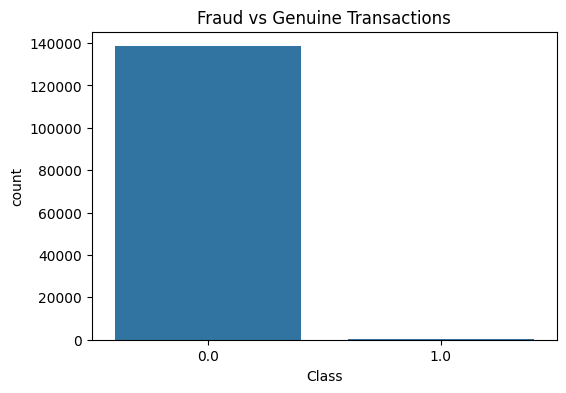

In [32]:
plt.figure(figsize=(6,4))

sns.countplot(x='Class', data=df)

plt.title("Fraud vs Genuine Transactions")

plt.show()

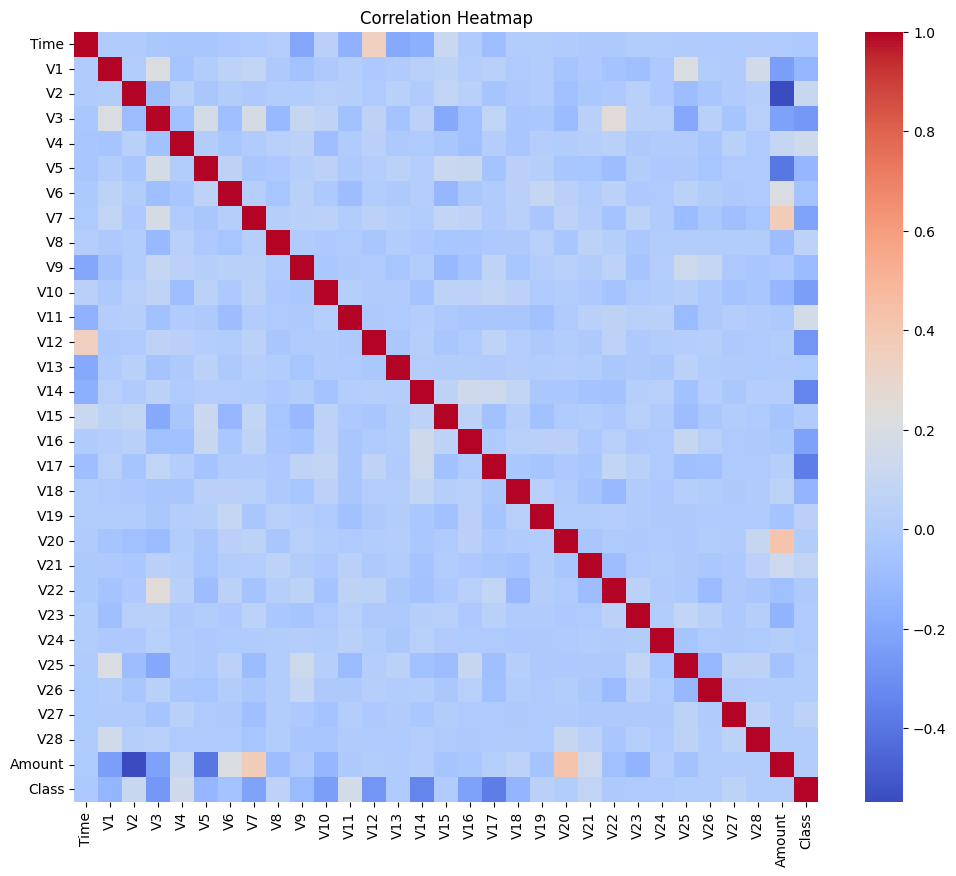

In [33]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [34]:
scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(
    df[['Amount']]
)

In [35]:
X = df.drop('Class', axis=1)

y = df['Class']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr_model.fit(
    X_train,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [38]:
lr_pred = lr_model.predict(X_test)

In [39]:
print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Precision:",
      precision_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("F1 Score:",
      f1_score(y_test, lr_pred))

print("ROC AUC:",
      roc_auc_score(y_test, lr_pred))

Accuracy: 0.9775094611641737
Precision: 0.07578008915304606
Recall: 0.9622641509433962
F1 Score: 0.14049586776859505
ROC AUC: 0.9699013951308053


In [40]:
print(
    classification_report(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     27692
         1.0       0.08      0.96      0.14        53

    accuracy                           0.98     27745
   macro avg       0.54      0.97      0.56     27745
weighted avg       1.00      0.98      0.99     27745



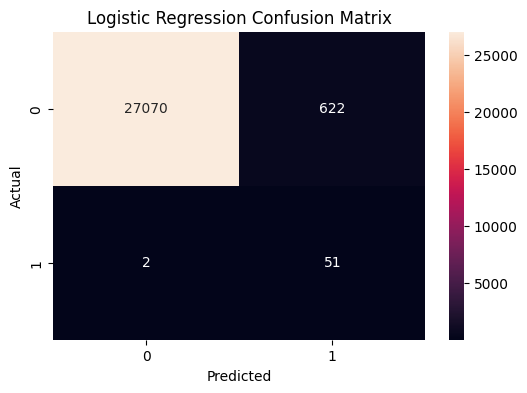

In [41]:
cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [42]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [43]:
rf_pred = rf_model.predict(X_test)

In [44]:
print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Precision:",
      precision_score(y_test, rf_pred))

print("Recall:",
      recall_score(y_test, rf_pred))

print("F1 Score:",
      f1_score(y_test, rf_pred))

print("ROC AUC:",
      roc_auc_score(y_test, rf_pred))

Accuracy: 0.9997116597585151
Precision: 0.9787234042553191
Recall: 0.8679245283018868
F1 Score: 0.92
ROC AUC: 0.9339442083947683


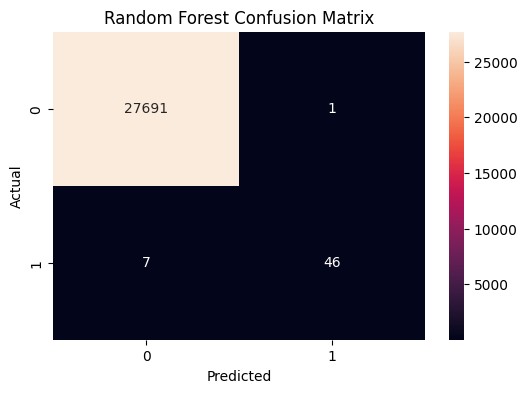

In [45]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [46]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.977509,0.075780,0.962264,0.140496
1,Random Forest,0.999712,0.978723,0.867925,0.920000


In [47]:
import pickle

pickle.dump(
    rf_model,
    open(
        "fraud_model.pkl",
        "wb"
    )
)

print("Model Saved")

Model Saved


In [48]:
from google.colab import files

files.download(
    "fraud_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>